# Perturbation results

Plots from saved results.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.ticker import MaxNLocator
from IPython.display import display
DATASET = 'Mcardiac_EA'
cwd = Path.cwd().resolve()
if (cwd / "analysis_results").is_dir() and (cwd / "perturb.ipynb").is_file():
    HERE = cwd
else:
    HERE = next(p / "experiments" / DATASET / "perturb"
                for p in [cwd, *cwd.parents]
                if (p / "experiments" / DATASET / "perturb" / "analysis_results").is_dir())
DATA = HERE / "analysis_results"
OUTPUT = DATA / "figures"
OUTPUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.facecolor": "#111111", "axes.facecolor": "#111111",
    "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white",
    "ytick.color": "white", "axes.edgecolor": "white", "font.family": "DejaVu Sans"})
def style_axis(ax):
    ax.set_facecolor("none")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color("white")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.grid(False)
def finish(fig, name):
    fig.savefig(OUTPUT / (name + ".png"), dpi=300, transparent=True, bbox_inches="tight")
    fig.patch.set_alpha(1)
    fig.patch.set_facecolor("#111111")
    plt.show()

## Perturbation accuracy

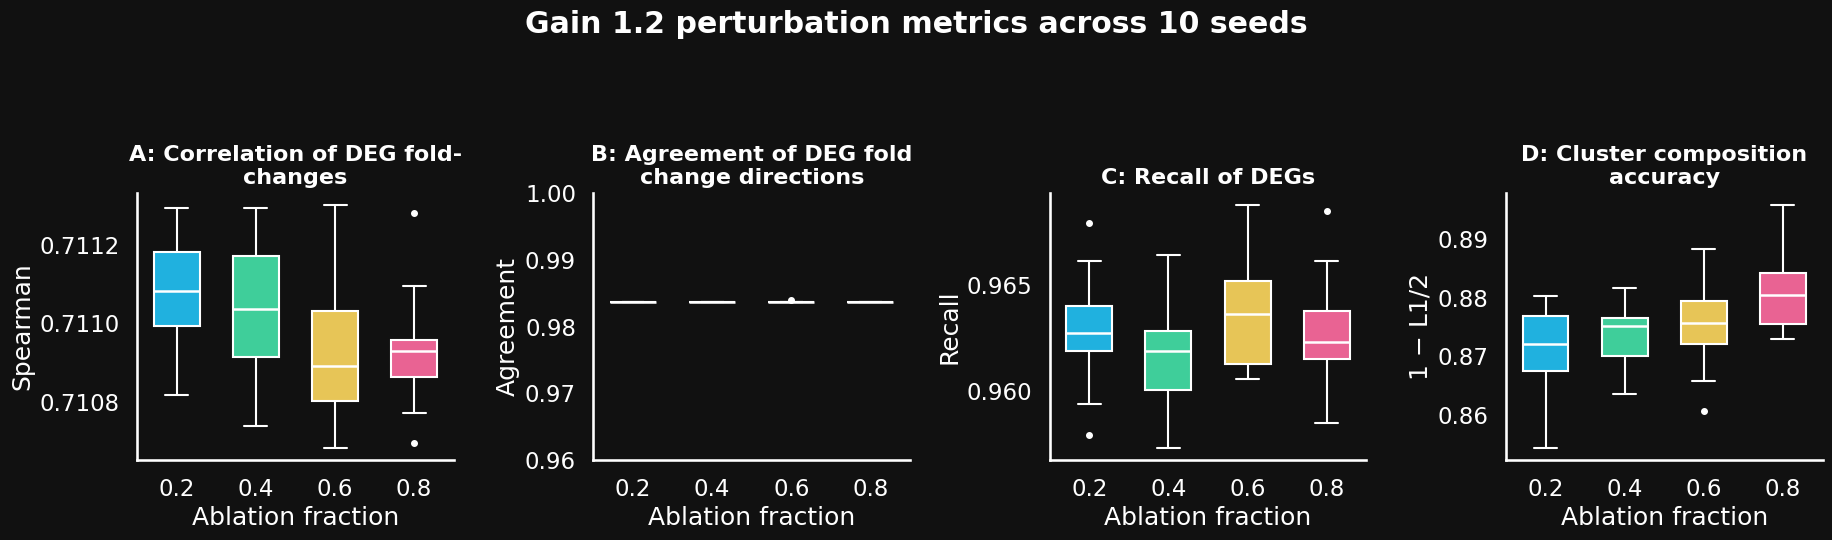

In [2]:
import seaborn as sns
sns.set_theme(style="white", context="talk")
metrics = pd.read_csv(DATA / "metrics_by_seed.csv")
order = [0.2, 0.4, 0.6, 0.8]
palette = dict(zip(order, ["#00C2FF", "#27E6A1", "#FFD23F", "#FF4D8D"]))
panels = [
    ("A", "spearman_log2fc", "Correlation of DEG fold-changes"),
    ("B", "direction_agreement_all_real_deg", "Agreement of DEG fold change directions"),
    ("C", "all_deg_recall", "Recall of DEGs"),
    ("D", "cell_composition_accuracy", "Cluster composition accuracy")]
assert len(metrics) == 40 and metrics.groupby("ablation_fraction").size().eq(10).all()
fig, axes = plt.subplots(1, 4, figsize=(28 / 6 * 4, 5.5))
for ax, (letter, column, title) in zip(axes, panels):
    sns.boxplot(data=metrics, x="ablation_fraction", y=column, hue="ablation_fraction",
                order=order, hue_order=order, palette=palette, legend=False,
                width=0.58, linewidth=1.5, showfliers=True, ax=ax,
                boxprops={"edgecolor": "white"}, whiskerprops={"color": "white"},
                capprops={"color": "white"}, medianprops={"color": "white", "linewidth": 1.8},
                flierprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "white", "markersize": 4})
    ax.set_xticks(range(4), ["0.2", "0.4", "0.6", "0.8"])
    ax.set_xlabel("Ablation fraction", color="white")
    ax.set_ylabel({"A": "Spearman", "B": "Agreement", "C": "Recall", "D": "1 − L1/2"}[letter], color="white")
    ax.set_title(letter + ": " + "\n".join(__import__("textwrap").wrap(title, 26)),
                 fontsize=16, fontweight="bold", color="white")
    if letter == "B": ax.set_ylim(0.96, 1.00)
    style_axis(ax)
    ax.tick_params(colors="white")
fig.suptitle("Gain 1.2 perturbation metrics across 10 seeds", fontweight="bold", color="white", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.90])
finish(fig, "gain1p2_multiseed_metrics_ABCD")

## Local expression changes

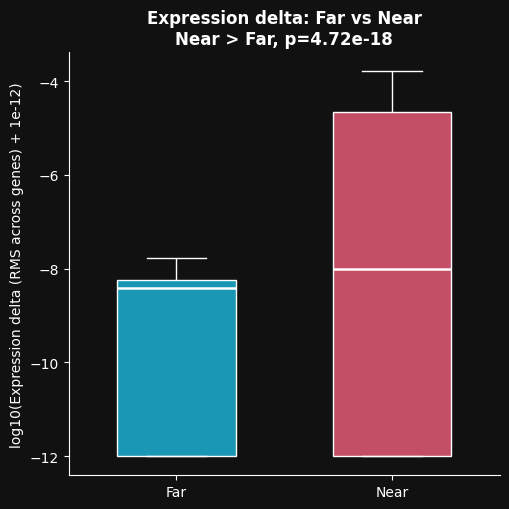

In [3]:
import seaborn as sns
sns.reset_defaults()
plt.style.use("dark_background")
palette = {"Far": "#00A7CE", "Near": "#D83A5B"}
def locality_boxplot(filename, value_column, title, ylabel):
    data = pd.read_csv(DATA / filename)
    data = data.loc[data.proximity_group.isin(["Far", "Near"])].copy()
    near = data.loc[data.proximity_group.eq("Near"), value_column]
    far = data.loc[data.proximity_group.eq("Far"), value_column]
    p = stats.mannwhitneyu(near, far, alternative="greater").pvalue
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    sns.boxplot(data=data, x="proximity_group", y="plot_value", hue="proximity_group",
                order=["Far", "Near"], hue_order=["Far", "Near"], palette=palette,
                legend=False, width=0.55, showfliers=True, ax=ax,
                boxprops={"edgecolor": "white"}, whiskerprops={"color": "white"},
                capprops={"color": "white"}, medianprops={"color": "white", "linewidth": 1.8},
                flierprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "white", "markersize": 3})
    ax.set_title(f"{title}\nNear > Far, p={p:.2e}", fontweight="bold", color="white")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, color="white")
    style_axis(ax)
    fig.tight_layout()
    finish(fig, filename.replace(".csv", ""))
locality_boxplot("Fig1.csv", "expression_delta_rms", "Expression delta: Far vs Near",
                 "log10(Expression delta (RMS across genes) + 1e-12)")

## Local coordinate changes

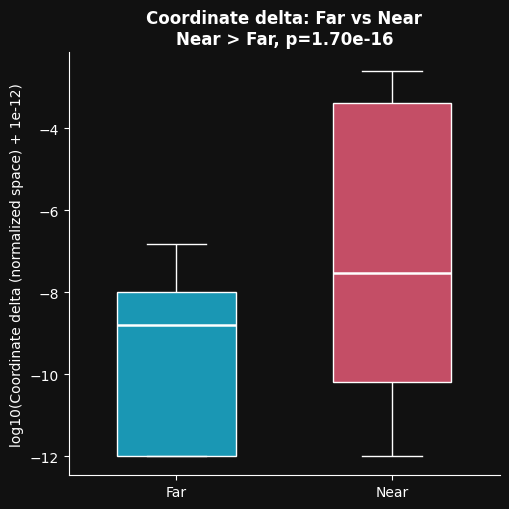

In [4]:
locality_boxplot("Fig2.csv", "coordinate_delta_normalized_space", "Coordinate delta: Far vs Near",
                 "log10(Coordinate delta (normalized space) + 1e-12)")

## Spatial intensity of changes

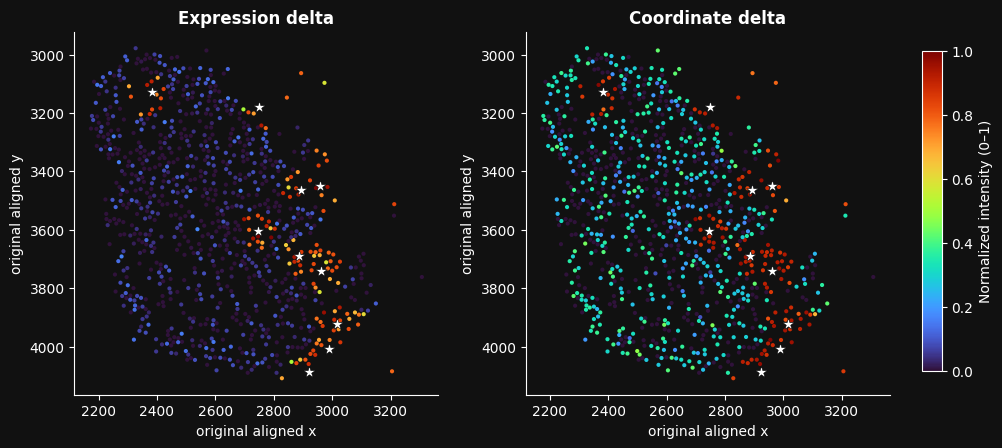

In [5]:
data = pd.read_csv(DATA / "Fig3.csv")
deleted = pd.read_csv(DATA / "deleted_ep_coordinates.csv")
fig, axes = plt.subplots(1, 2, figsize=(10.8, 5))
for ax, column, title in zip(axes,
        ["expression_intensity_normalized", "coordinate_intensity_normalized"],
        ["Expression delta", "Coordinate delta"]):
    plotted = ax.scatter(data.original_x, data.original_y, c=data[column], cmap="turbo",
                         vmin=0, vmax=1, s=9, linewidths=0, rasterized=True)
    ax.scatter(deleted.original_x, deleted.original_y, marker="*", s=75,
               c="white", edgecolors="black", linewidths=0.35)
    ax.set_title(title, color="white", fontweight="bold")
    ax.set_xlabel("original aligned x")
    ax.set_ylabel("original aligned y")
    ax.invert_yaxis()
    ax.set_aspect("equal")
    style_axis(ax)
fig.subplots_adjust(right=0.88, wspace=0.24)
cax = fig.add_axes([0.91, 0.18, 0.018, 0.64])
cb = fig.colorbar(plotted, cax=cax)
cb.set_label("Normalized intensity (0–1)", color="white")
cb.ax.tick_params(colors="white")
finish(fig, "Fig3")